In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az
tfd = tfp.distributions

import meridian
from meridian import constants
from meridian.analysis import analyzer, optimizer, summarizer, visualizer
from meridian.analysis.review import reviewer
from meridian.data import data_frame_input_data_builder
from meridian.model import model, prior_distribution, spec, transformers

print(f"Meridian {meridian.__version__} ready")
print(f"TF devices: {tf.config.list_physical_devices()}")

Meridian 1.5.3 ready
TF devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [6]:
raw_data = pd.read_csv("/Users/russellwhealdon/mmm-workspace/data/raw/Freedom_Power/Freedom_MMM_data_Mar26.csv")

### Add in Context Variables

Tax Credit

In [9]:
# Tax credit regime shift indicator
policy_change_date = pd.Timestamp("2025-10-01")

raw_data["tax_credit_shift"] = (
    raw_data["date"] >= policy_change_date
).astype(np.float32)

TypeError: '>=' not supported between instances of 'str' and 'Timestamp'

Storm Dates

In [ ]:
storm_start_date = pd.Timestamp("2024-06-01")
storm_end_date = pd.Timestamp("2024-07-01")

raw_data["storm_date"] = (
    (raw_data["date"] >= storm_start_date) & (raw_data["date"] < storm_end_date)
).astype(np.float32)

### Ensure we have rows for all dates/geos

In [ ]:
# 1. Ensure 'date' is a proper datetime object
raw_data['date'] = pd.to_datetime(raw_data['date'])

# 2. Get the unique list of all dates and all geos
all_dates = raw_data['date'].unique()
all_geos = raw_data['geo'].unique()

# 3. Create a 'Perfect Index' of all possible combinations
perfect_index = pd.MultiIndex.from_product(
    [all_dates, all_geos],
    names=['date', 'geo']
)
perfect_df = pd.DataFrame(index=perfect_index).reset_index()

# 4. Merge your data into the perfect structure
# Use 'left' join so we keep every date/geo combo, filling missing with 0
raw_data = pd.merge(perfect_df, raw_data, on=['date', 'geo'], how='left').fillna(0)

# 5. Sort to ensure alignment (VERY important for Meridian)
raw_data = raw_data.sort_values(['geo', 'date']).reset_index(drop=True)

print(f"Data Re-aligned! Total rows should be {len(all_dates) * len(all_geos)}.")
print(f"Current rows: {len(raw_data)}")

Data Re-aligned! Total rows should be 1608.
Current rows: 1608


In [ ]:
# Create a list of the low-volume geos we identified
geos_to_drop = ['Carolinas', 'Denver', 'Virginia', 'Colorado Springs', 'Richmond', 'OOT']

# Filter the dataframe to keep only rows where the geo is NOT in that list
raw_data = raw_data[~raw_data['geo'].isin(geos_to_drop)].reset_index(drop=True)

# Verify the change
print(f"Remaining regions: {raw_data['geo'].unique()}")

Remaining regions: ['Austin' 'DFW' 'Houston' 'Orlando' 'San Antonio' 'Tampa']


### Assign populations to each geo

In [ ]:
# Create the mapping dictionary
dma_population_map = {
    'DFW': 3264490,
    'Houston': 2797420,
    'Tampa': 2221240,
    'Orlando': 1902420,
    'Denver': 1806270,
    'Carolinas': 1382020,
    'San Antonio': 1096400,
    'Austin': 1029800,
    'Virginia': 625380,
    'Colorado Springs': 388730
}

# Assign to your dataframe
# This looks at your 'geo' column and creates a 'population' column based on the map
raw_data['population'] = raw_data['geo'].map(dma_population_map)

# Double check for any missing values (typos in geo names)
missing_count = raw_data['population'].isna().sum()
if missing_count > 0:
    print(f"Warning: {missing_count} rows have no population mapping. Check your geo names!")
else:
    print("Population mapping successful!")

Population mapping successful!


In [ ]:
raw_data.date.min()

Timestamp('2023-10-09 00:00:00')

### Build Transformers

### Build Priors

In [ ]:
# ==========================================================
# 1. CHANNELS + TYPE CASTING (NO MANUAL SCALING)
# ==========================================================
channels = ['Non_Brand', 'Brand', 'DVD', 'Retargeting', 'Prospecting']

# KPI: just cast to float32 (Meridian will scale internally)
raw_data['Gross_Leads'] = raw_data['Gross_Leads'].astype(np.float32)

# Media: just cast to float32 (Meridian will scale internally)
for chan in channels:
    raw_data[f'{chan}_Cost'] = raw_data[f'{chan}_Cost'].astype(np.float32)
    raw_data[f'{chan}_Impressions'] = raw_data[f'{chan}_Impressions'].astype(np.float32)

# Population: cast to float32
raw_data['population'] = raw_data['population'].astype(np.float32)

In [ ]:
raw_data.to_csv('Freedom_MMM_data.csv', index=False)

In [ ]:
# ==========================================================
# 2. INPUT DATA BUILDER
# ==========================================================
builder = data_frame_input_data_builder.DataFrameInputDataBuilder(kpi_type='non_revenue')

builder = builder.with_kpi(
    raw_data,
    kpi_col='Gross_Leads',
    time_col='date',
    geo_col='geo'
)

builder = builder.with_media(
    raw_data,
    media_channels=channels,
    media_spend_cols=[f'{c}_Cost' for c in channels],
    media_cols=[f'{c}_Impressions' for c in channels],
    time_col='date',
    geo_col='geo'
)

builder = builder.with_controls(
    raw_data,
    control_cols=["tax_credit_shift", "storm_date"],
    time_col="date",
    geo_col="geo"
)


builder = builder.with_population(
    raw_data,
    population_col='population',
    geo_col='geo'
)

input_data = builder.build()

/usr/local/lib/python3.12/dist-packages/meridian/data/input_data.py:525: UserWarning: Consider setting custom priors, as kpi_type was specified as `non_revenue` with no `revenue_per_kpi` being set. Otherwise, the total media contribution prior will be used with `p_mean=0.4` and `p_sd=0.2`. Further documentation available at https://developers.google.com/meridian/docs/advanced-modeling/unknown-revenue-kpi-custom#set-total-paid-media-contribution-prior
  warnings.warn(


In [ ]:
# ==========================================================
# 3. PRIOR SPECIFICATION (Contribution-prior mode)
# ==========================================================
# Target total paid media contribution share (across ALL paid channels)
target_contribution = 0.60  # <- change this

# Split that target evenly across channels for the PRIOR mean
# (Meridian's contribution_m is per-channel; this sets a symmetric prior)
per_channel_mean = target_contribution / len(channels)

# Concentration controls how tight the prior is around the mean:
# higher = tighter, lower = looser
concentration = 50.0

a = per_channel_mean * concentration
b = (1.0 - per_channel_mean) * concentration

my_priors = prior_distribution.PriorDistribution(
    contribution_m=tfp.distributions.Beta(
        concentration1=tf.cast([a] * len(channels), tf.float32),
        concentration0=tf.cast([b] * len(channels), tf.float32)
    )
)


In [ ]:
n_weeks = len(raw_data['date'].unique())

In [ ]:
# ==========================================================
# 4. MODEL SPEC & EXECUTION
# ==========================================================

model_spec = spec.ModelSpec(
    prior=my_priors,
    media_prior_type='contribution',
    knots=n_weeks // 2,
    max_lag=4,
    media_effects_dist='log_normal'
)

mmm = model.Meridian(input_data=input_data, model_spec=model_spec)

#### Model Spec with Holdout

In [ ]:
# # ==========================================================
# # HOLDOUT SETUP (Time-based) — Meridian expects shape (n_geos, n_times)
# # ==========================================================
# holdout_weeks = 4

# # Make sure ordering matches your builder: sort by geo then date
# df = raw_data.sort_values(["geo", "date"]).reset_index(drop=True)

# # Identify the last N time points (global across geos)
# dates = np.sort(df["date"].unique())
# holdout_start_date = dates[-holdout_weeks]

# # Create a 2D holdout mask: (n_geos, n_times)
# # Same dates are held out for every geo
# holdout_time = (dates >= holdout_start_date).astype(int)          # shape (n_times,)
# holdout_id = np.tile(holdout_time, (df["geo"].nunique(), 1))      # shape (n_geos, n_times)

# # ==========================================================
# # MODEL SPEC WITH HOLDOUT
# # ==========================================================
# model_spec = spec.ModelSpec(
#     prior=my_priors,
#     media_prior_type='contribution',
#     knots=n_weeks // 2,
#     max_lag=4,
#     media_effects_dist='log_normal',
#     holdout_id=holdout_id
# )

# mmm = model.Meridian(input_data=input_data, model_spec=model_spec)

### Run Model

In [ ]:
# Sample
mmm.sample_prior(1000)
mmm.sample_posterior(
    n_chains=1,
    n_adapt=200,
    n_burnin=200,
    n_keep=200,
    seed=42,
)

### Review Model

In [ ]:
reviewer.ModelReviewer(mmm).run()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:676: RuntimeWarning: divide by zero encountered in divide
  return backend.nanmean(backend.absolute((actual - expected) / actual))


Model Quality Checks
Overall Status: PASS
Summary: Passed: No major quality issues were identified.
Health Score: 99.4

Check Results:
----------------------------------------
Convergence Check:
  Status: PASS
  Recommendation: The model has likely converged, as all parameters have R-hat values < 1.2.
----------------------------------------
Baseline Check:
  Status: PASS
  Recommendation: The posterior probability that the baseline is negative is 0.06. We recommend visually inspecting the baseline time series in the Model Fit charts to confirm this.
----------------------------------------
BayesianPPP Check:
  Status: PASS
  Recommendation: The Bayesian posterior predictive p-value is 0.96. The observed total outcome is consistent with the model's posterior predictive distribution.
----------------------------------------
GoodnessOfFit Check:
  Status: PASS
  Recommendation: R-squared = 0.7045, MAPE = inf, and wMAPE = 0.2195. These goodness-of-fit metrics are intended for guidance and

In [ ]:
import arviz as az

idata = mmm.inference_data

## Core health check

**mean**: Posterior mean estimate of the parameter.

**sd**: Posterior standard deviation → uncertainty.

**hdi_3% / hdi_97%:** 94% highest-density interval (credible interval). This is your Bayesian “confidence interval.”

**mcse_mean / mcse_sd**: Monte Carlo standard error.
→ Should be small relative to sd.

**ess_bulk / ess_tail**: Effective sample size (bulk & tails).
→ Measures how well the chains mixed.

**r_hat**: Convergence diagnostic.
→ Should be very close to 1.0.

In [ ]:
az.summary(
    idata,
    var_names=[
        "beta_m",
        "alpha_m",
        "ec_m",
        "sigma"
    ],
    round_to=3
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_m[Non_Brand],-1.037,0.755,-2.484,0.321,0.011,0.008,4485.268,5357.869,1.000
beta_m[Brand],-1.371,0.994,-3.259,0.170,0.013,0.009,5800.564,6026.703,1.001
beta_m[DVD],-1.934,0.875,-3.532,-0.526,0.013,0.009,4166.443,6123.149,1.000
beta_m[Retargeting],-2.081,1.024,-4.012,-0.380,0.015,0.011,4200.216,5791.034,1.001
beta_m[Prospecting],0.625,0.530,-0.455,1.507,0.009,0.006,3500.736,4673.818,1.001
alpha_m[Non_Brand],0.173,0.191,0.000,0.553,0.003,0.002,6342.628,4401.428,1.001
alpha_m[Brand],0.104,0.111,0.000,0.292,0.001,0.001,6708.973,3802.682,1.000
alpha_m[DVD],0.395,0.295,0.000,0.901,0.004,0.003,4758.156,5586.508,1.000
alpha_m[Retargeting],0.684,0.231,0.253,1.000,0.003,0.002,6540.475,4910.745,1.001
alpha_m[Prospecting],0.223,0.160,0.000,0.507,0.003,0.002,3362.804,4428.502,1.000


### Model Output

In [ ]:
from meridian.analysis import summarizer

# 1. Initialize the summarizer
summary = summarizer.Summarizer(mmm)

# 2. Get the core summary table
# This will show Spend, Incremental Leads, ROI, and mROI (Marginal ROI)
# roi_table = summary.kpi_summary_table()
# print(roi_table)

summary

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


In [ ]:
# Plot the contribution pie chart using the summarizer object
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/visualizer.py:1678: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental KPI,% contribution,roi,effectiveness,mroi,cpik
0,Non_Brand,prior,"15,932,294",11.2%,"7,336,043",68%,$460,"9,146 (4,067, 15,426)","7% (3%, 12%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$836 ($476, $1,804)"
1,Non_Brand,posterior,"15,932,294",11.2%,"7,336,043",68%,$460,"13,197 (7,038, 19,860)","17% (9%, 26%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$562 ($369, $1,042)"
2,Brand,prior,"219,276",0.2%,"367,945",3%,"$1,678","9,043 (4,050, 14,889)","7% (3%, 12%)","0.0 (0.0, 0.0)","0.04 (0.02, 0.07)","0.0 (0.0, 0.0)","$43 ($25, $91)"
3,Brand,posterior,"219,276",0.2%,"367,945",3%,"$1,678","11,966 (7,178, 17,372)","16% (9%, 23%)","0.0 (0.0, 0.0)","0.05 (0.03, 0.08)","0.0 (0.0, 0.0)","$31 ($21, $51)"
4,DVD,prior,"52,791,908",37.2%,"762,911",7%,$14,"9,137 (4,420, 14,991)","7% (3%, 12%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$88 ($51, $173)"
5,DVD,posterior,"52,791,908",37.2%,"762,911",7%,$14,"5,581 (2,823, 8,979)","7% (4%, 12%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$142 ($85, $270)"
6,Retargeting,prior,"4,207,686",3.0%,"147,162",1%,$35,"9,027 (3,870, 14,736)","7% (3%, 12%)","0.1 (0.0, 0.1)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$17 ($10, $38)"
7,Retargeting,posterior,"4,207,686",3.0%,"147,162",1%,$35,"7,703 (4,461, 11,453)","10% (6%, 15%)","0.1 (0.0, 0.1)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$20 ($13, $33)"
8,Prospecting,prior,"68,610,256",48.4%,"2,217,132",20%,$32,"9,198 (4,270, 15,434)","7% (3%, 12%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$249 ($144, $519)"
9,Prospecting,posterior,"68,610,256",48.4%,"2,217,132",20%,$32,"28,046 (22,601, 33,675)","37% (30%, 44%)","0.0 (0.0, 0.0)","0.00 (0.00, 0.00)","0.0 (0.0, 0.0)","$79 ($66, $98)"


In [ ]:
from meridian.analysis import visualizer

# Initialize the visualizer
vis = visualizer.MediaEffects(mmm)

# Plot the curves
# The 'Hill' curve shows how leads grow relative to spend
vis.plot_response_curves()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


alt.FacetChart(...)

In [ ]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


alt.LayerChart(...)

### Full Model Output

### Geo Specific Output

In [ ]:
# The media_summary object was already created using visualizer.MediaSummary in a previous cell.
# We can directly call its summary_table method without the 'by_geo' argument, as it's not supported here.
m_analyzer = analyzer.Analyzer(mmm)
geo_metrics_basline = m_analyzer.baseline_summary_metrics(aggregate_geos=False, use_kpi=True)
geo_baseline_df = geo_metrics_basline.to_dataframe().reset_index()

geo_metrics = m_analyzer.summary_metrics(aggregate_geos=False, use_kpi=True)
geo_df = geo_metrics.to_dataframe().reset_index()

/tmp/ipykernel_8428/2190216015.py:3: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  m_analyzer = analyzer.Analyzer(mmm)


In [ ]:
geo_df

,geo,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
0,Austin,Non_Brand,mean,prior,1875607.0,12.174837,998820.375,74.729164,532.531799,874.085876,8.732681,0.000875,0.000466,0.000310,70612.414062
1,Austin,Non_Brand,mean,posterior,1875607.0,12.174837,998820.375,74.729164,532.531799,4229.945801,36.842415,0.004235,0.002255,0.001644,258.383270
2,Austin,Non_Brand,median,prior,1875607.0,12.174837,998820.375,74.729164,532.531799,648.283691,6.476771,0.000649,0.000346,0.000212,1540.717285
3,Austin,Non_Brand,median,posterior,1875607.0,12.174837,998820.375,74.729164,532.531799,4154.347656,36.183937,0.004159,0.002215,0.001643,240.427734
4,Austin,Non_Brand,ci_lo,prior,1875607.0,12.174837,998820.375,74.729164,532.531799,56.000511,0.559481,0.000056,0.000030,0.000018,390.989594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Tampa,All Channels,median,posterior,13045727.0,100.000000,1116911.000,100.000000,85.615082,6683.608887,72.511902,0.005984,NaN,NaN,167.111969
284,Tampa,All Channels,ci_lo,prior,13045727.0,100.000000,1116911.000,100.000000,85.615082,2195.232422,13.492036,0.001965,NaN,NaN,128.900436
285,Tampa,All Channels,ci_lo,posterior,13045727.0,100.000000,1116911.000,100.000000,85.615082,5043.584473,54.718925,0.004516,NaN,NaN,134.691879
286,Tampa,All Channels,ci_hi,prior,13045727.0,100.000000,1116911.000,100.000000,85.615082,8664.948242,53.255314,0.007758,NaN,NaN,508.789398


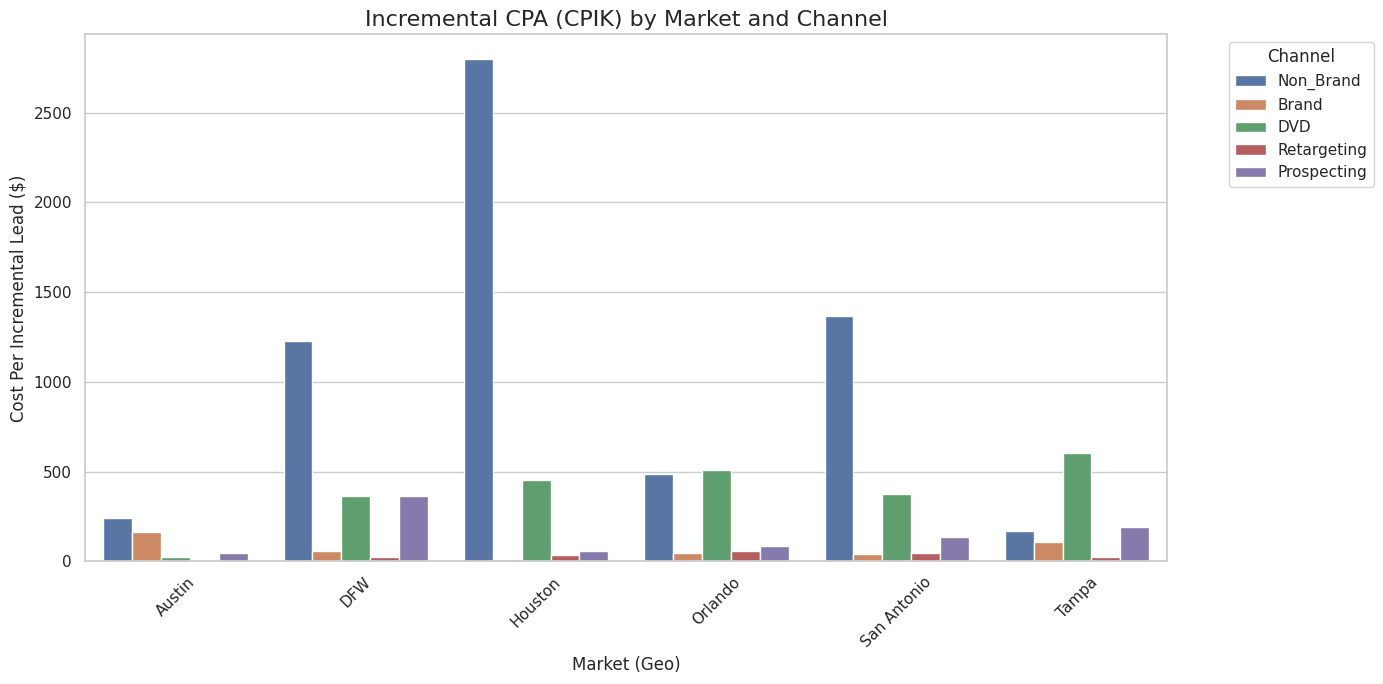

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the actual model results: Posterior Median
plot_df = geo_df[(geo_df['distribution'] == 'posterior') & (geo_df['metric'] == 'median') & (geo_df['channel'] != 'All Channels')].copy()


# Set plot style
sns.set_theme(style="whitegrid")

# --- PLOT 1: Incremental CPA by Market & Channel ---
plt.figure(figsize=(14, 7))
ax1 = sns.barplot(data=plot_df, x='geo', y='cpik', hue='channel')
plt.title('Incremental CPA (CPIK) by Market and Channel', fontsize=16)
plt.ylabel('Cost Per Incremental Lead ($)', fontsize=12)
plt.xlabel('Market (Geo)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

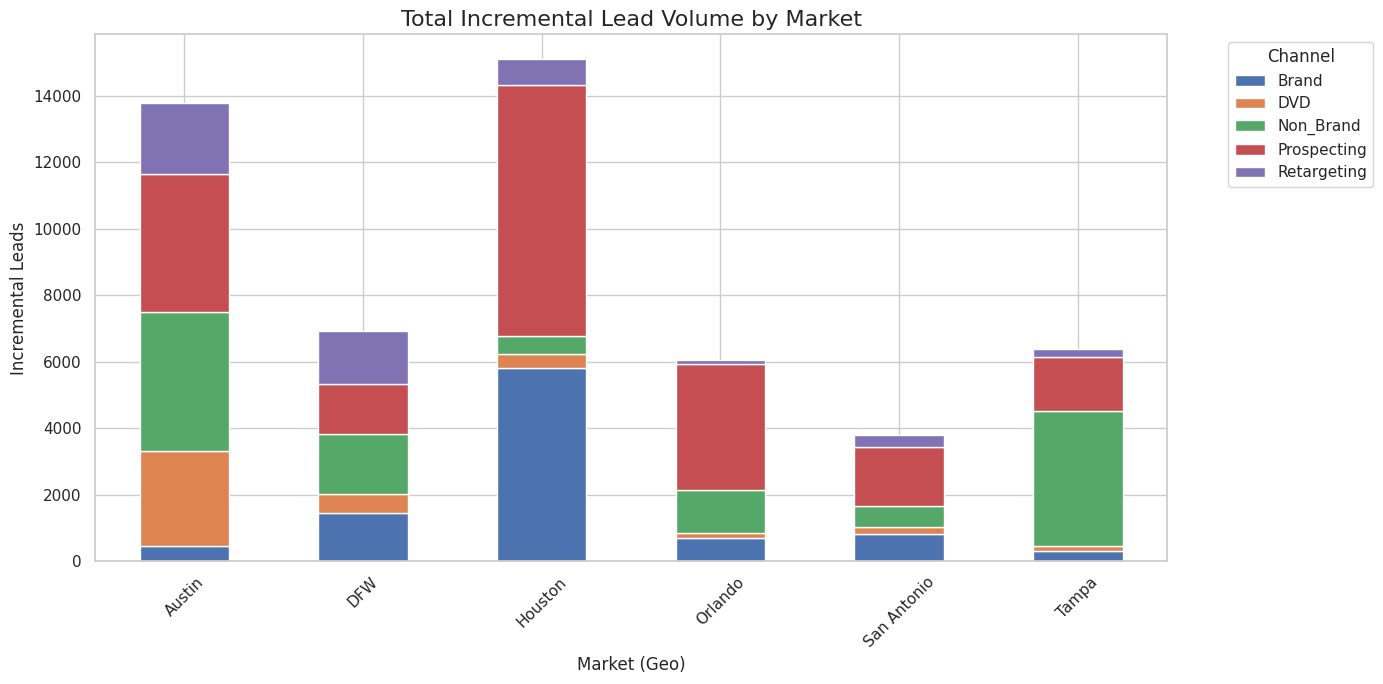

In [ ]:
pivot_df = plot_df.pivot(index='geo', columns='channel', values='incremental_outcome')

plt.figure(figsize=(14, 7))
pivot_df.plot(kind='bar', stacked=True, figsize=(14, 7), ax=plt.gca())
plt.title('Total Incremental Lead Volume by Market', fontsize=16)
plt.ylabel('Incremental Leads', fontsize=12)
plt.xlabel('Market (Geo)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

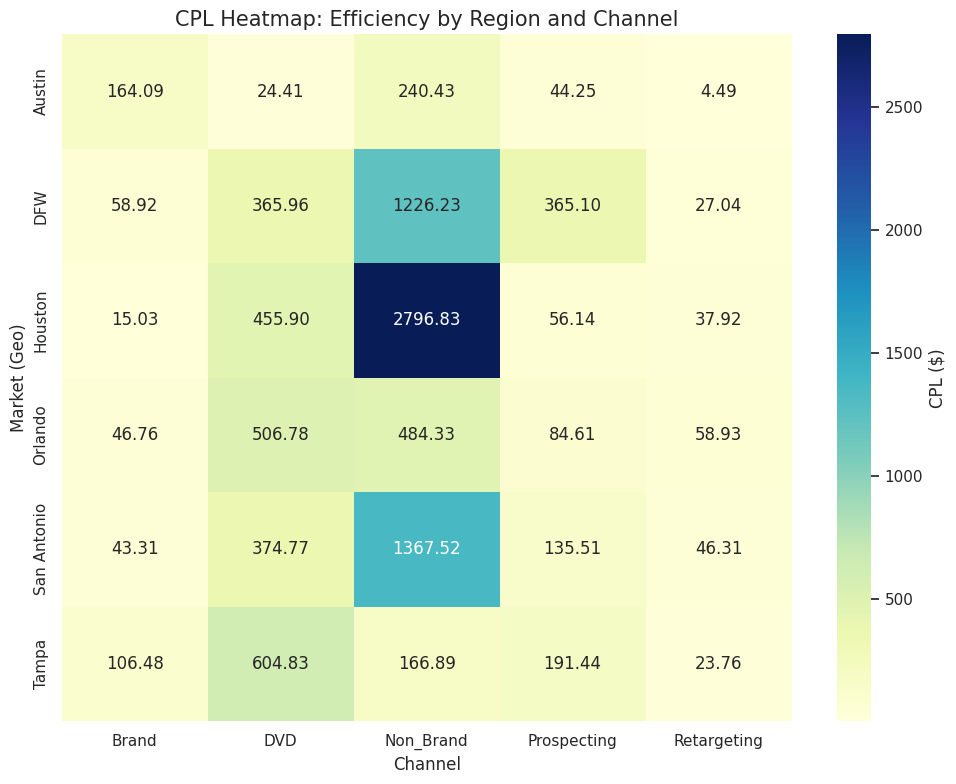

In [ ]:
# --- PLOT 3: CPA Heatmap by Region (Efficiency View) ---
heatmap_data = plot_df.pivot(index='geo', columns='channel', values='cpik')

plt.figure(figsize=(10, 8))
# We remove cbar_kws to avoid the error and set it manually below
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu')

plt.title('CPL Heatmap: Efficiency by Region and Channel', fontsize=15)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Market (Geo)', fontsize=12)

# Set the colorbar label manually
cbar = ax.collections[0].colorbar
cbar.set_label('CPL ($)', fontsize=12)

plt.tight_layout()
plt.show()

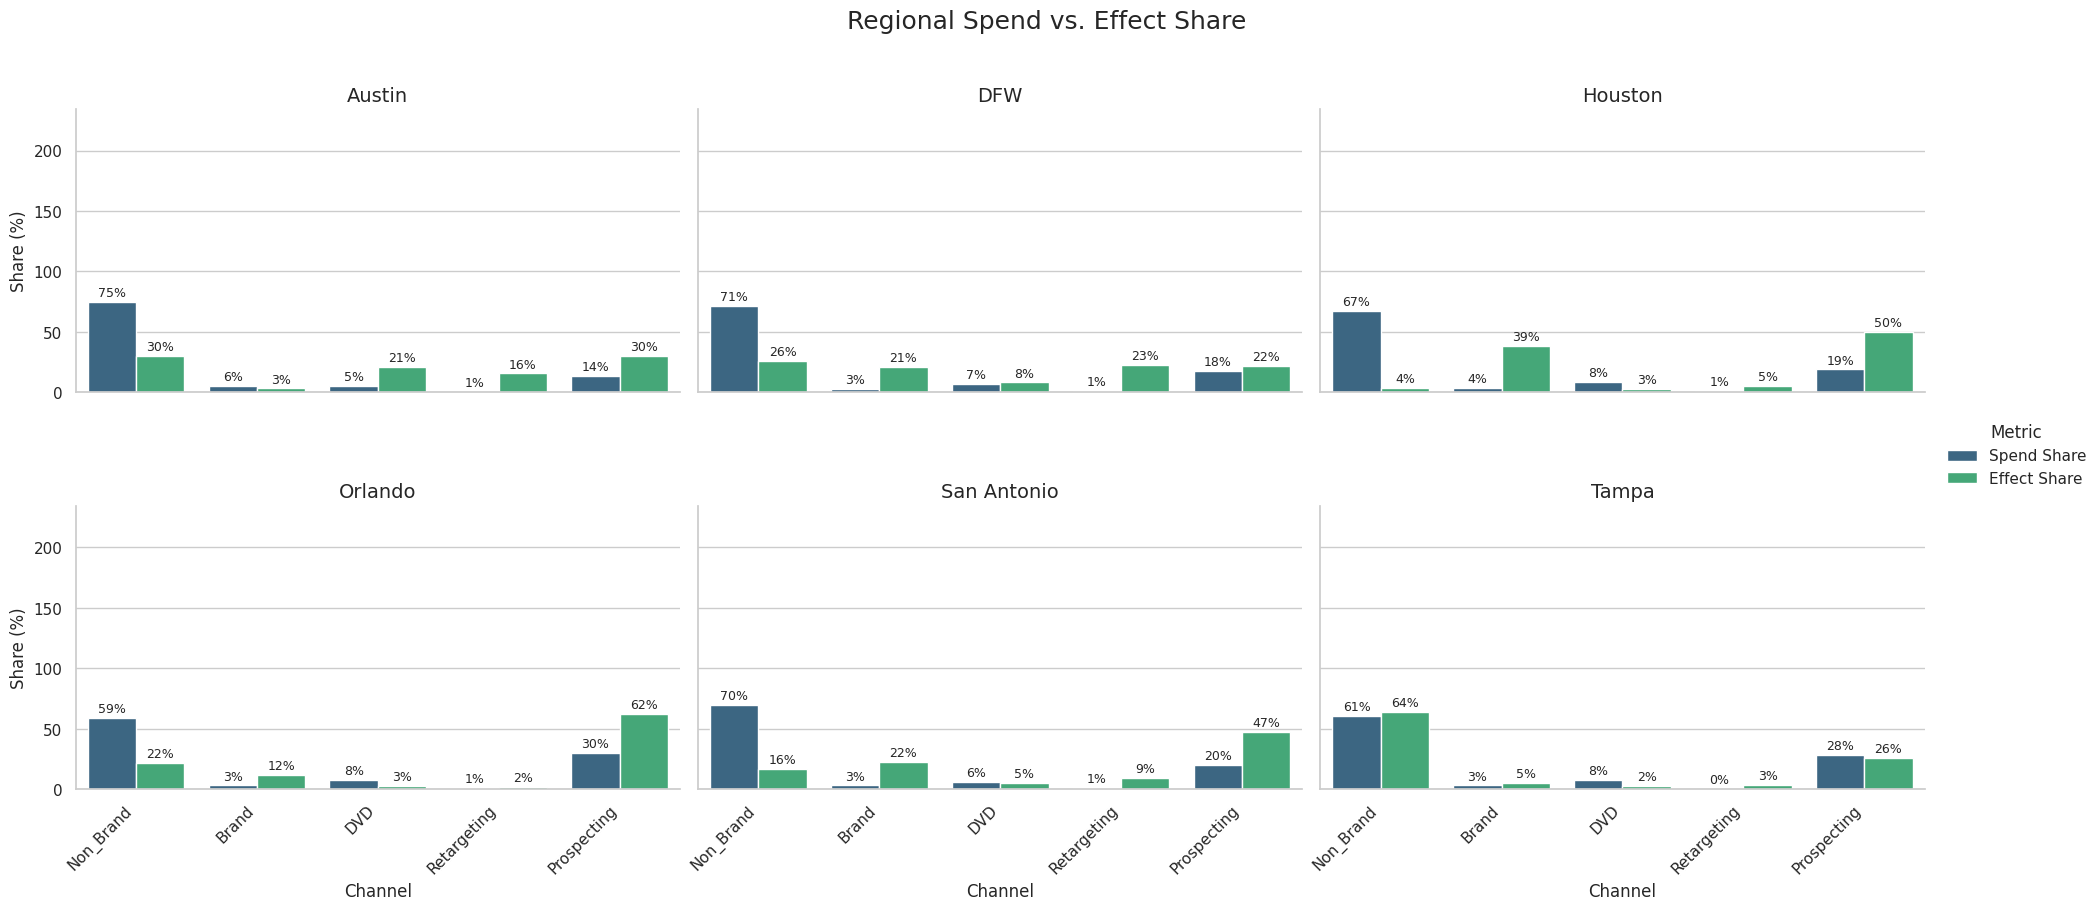

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1. Calculate shares within each specific Geo
geo_totals = plot_df.groupby('geo').agg({
    'spend': 'sum',
    'incremental_outcome': 'sum'
}).rename(columns={'spend': 'total_geo_spend', 'incremental_outcome': 'total_geo_incremental'})

geo_shares = plot_df.merge(geo_totals, on='geo')
geo_shares['Spend Share'] = (geo_shares['spend'] / geo_shares['total_geo_spend']) * 100
geo_shares['Effect Share'] = (geo_shares['incremental_outcome'] / geo_shares['total_geo_incremental']) * 100

melted_geo = geo_shares.melt(
    id_vars=['geo', 'channel'],
    value_vars=['Spend Share', 'Effect Share'],
    var_name='Metric',
    value_name='Percentage'
)

# 2. Create the faceted plot
g = sns.catplot(
    data=melted_geo, kind="bar",
    x="channel", y="Percentage", hue="Metric",
    col="geo", col_wrap=3,
    palette="viridis", height=5, aspect=1.3
)

g.set_axis_labels("Channel", "Share (%)")
g.set_titles("{col_name}", size=14)

# --- ADD LABELS AND ROTATION TO EVERY SUBPLOT ---
for ax in g.axes.flat:
    # Rotate Labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Label each bar in this subplot
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=9)

    # Increase y-limit slightly so labels don't hit the top of the box
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.subplots_adjust(top=0.88, bottom=0.2, hspace=0.4)
g.fig.suptitle('Regional Spend vs. Effect Share', fontsize=18)
plt.show()

# FIX: Add extra space at the bottom for the rotated labels
plt.subplots_adjust(top=0.88, bottom=0.2)
g.fig.suptitle('Regional Spend vs. Effect Share', fontsize=18)
plt.show()

### Budget Optimzer

In [ ]:
from meridian.analysis import optimizer

In [ ]:
# ==========================================================
# BUDGET OPTIMIZER (Meridian 1.4.0)
# ==========================================================
# Runs a fixed-budget optimization by default and returns an OptimizationResults object.

budget_optimizer = optimizer.BudgetOptimizer(mmm)

In [ ]:
# ==========================================================
# CAN WE LOOK AT IT BY GEO?
# Yes — scope optimization to a subset of geos using create_optimization_grid(...selected_geos=...)
# ==========================================================

# Option A (simplest): just scope directly by geo
optimization_results_geo = budget_optimizer.optimize(
    fixed_budget=True,
    selected_geos=["Tampa"],   # <- change to any geo or list of geos
    # Optional: time window (can be within data range)
    start_date="2025-02-03",
    end_date="2025-02-24",
)

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1038: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  

### Apendix

Test Data

## Save settings to configs/Freedom_Power.yaml

In [ ]:
# ── Save current settings to configs/Freedom_Power.yaml ──────────────────────
# Run this cell when you're happy with the model spec and want to lock in
# these settings as the production config for the Colab runner.
# Push to GitHub before running on Colab.

import yaml
from pathlib import Path

# ── MCMC settings (edit to match your current sample_posterior call) ──────────
mcmc_dev  = dict(n_chains=1, n_adapt=200, n_burnin=200, n_keep=200)
mcmc_prod = dict(n_chains=4, n_adapt=500, n_burnin=500, n_keep=500)

# ── Contribution prior (pulled from variables defined above) ──────────────────
contribution_prior_params = dict(
    target_contribution=float(target_contribution),
    concentration=float(concentration),
)

# ── ModelSpec parameters ──────────────────────────────────────────────────────
modelspec_params = dict(
    media_prior_type="contribution",
    knots=int(n_weeks // 2),
    max_lag=4,
    media_effects_dist="log_normal",
)

# ── Controls ──────────────────────────────────────────────────────────────────
control_cols = ["tax_credit_shift", "storm_date"]

# ── Assemble and write ────────────────────────────────────────────────────────
config = {
    "client_id": "freedom_power",
    "kpi_column": "Gross_Leads",
    "kpi_type": "non_revenue",
    "date_column": "date",
    "geo_column": "geo",
    "channels": channels,
    "controls": control_cols,
    "contribution_prior": contribution_prior_params,
    "model_spec": modelspec_params,
    "mcmc": {
        "dev": mcmc_dev,
        "prod": mcmc_prod,
    },
}

config_path = Path("configs/Freedom_Power.yaml")
config_path.parent.mkdir(exist_ok=True)
with open(config_path, "w") as fh:
    yaml.dump(config, fh, default_flow_style=False, sort_keys=False)

print(f"Config saved to {config_path}")
print("Push to GitHub before running on Colab.")